#### Packages

In [1]:
%pip install pandas GEOparse openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [22]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


### Load Libraries

In [1]:
import pandas as pd
import GEOparse

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create plots directory if it doesn't exist
output_dir = "/media/mim/98f13536-4fbf-47cf-a5eb-647479dcaef1/personal-projects/bioinformatics_projects/python/plots/"
os.makedirs(output_dir, exist_ok=True)

### Read Expression Data

In [2]:
# Read the FPKM data
data = pd.read_csv("/media/mim/98f13536-4fbf-47cf-a5eb-647479dcaef1/personal-projects/bioinformatics_projects/data/GSE183947_fpkm.csv")

# Print dimensions (equivalent to dim(data))
print(data.shape)

# View the head
data.head()

(20246, 61)


,Unnamed: 0,CA.102548,CA.104338,CA.105094,CA.109745,CA.1906415,CA.1912627,CA.1924346,CA.1926760,CA.1927842,...,CAP.2040686,CAP.2046297,CAP.2046641,CAP.348981,CAP.354300,CAP.359448,CAP.94377,CAP.98389,CAP.98475,CAP.99145
0,TSPAN6,0.93,1.97,0.00,5.45,4.52,4.75,3.96,3.58,6.41,...,6.66,8.35,8.94,6.33,5.94,6.35,3.74,4.84,10.46,4.54
1,TNMD,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.23,0.39,...,0.12,0.17,1.08,0.29,0.00,0.07,9.19,1.18,0.09,0.39
2,DPM1,0.00,0.43,0.00,3.43,8.45,8.53,7.80,7.62,6.40,...,4.93,7.47,5.72,4.96,9.28,9.15,4.77,3.75,7.31,2.77
3,SCYL3,5.78,5.17,8.76,4.58,7.20,6.03,9.05,5.37,5.92,...,8.02,6.00,5.28,4.98,4.45,7.00,4.14,5.51,7.45,2.33
4,C1orf112,2.83,6.26,3.37,6.24,5.16,13.69,6.69,5.28,7.65,...,7.91,4.61,8.35,9.84,7.68,5.62,2.81,7.08,7.28,5.39


### Fetch Metadata via GEOparse

In [3]:
# Fetch metadata from NCBI GEO
gse = GEOparse.get_GEO(geo="GSE183947", destdir="./")

# Extract sample phenotypic characteristics (equivalent to pData)
# GEOparse stores characteristics as a dictionary/dataframe of GSM samples
metadata = gse.phenotype_data
metadata.head()

04-Jul-2026 18:35:20 DEBUG utils - Directory ./ already exists. Skipping.
04-Jul-2026 18:35:20 INFO GEOparse - File already exist: using local version.
04-Jul-2026 18:35:20 INFO GEOparse - Parsing ./GSE183947_family.soft.gz: 
04-Jul-2026 18:35:20 DEBUG GEOparse - DATABASE: GeoMiame
04-Jul-2026 18:35:20 DEBUG GEOparse - SERIES: GSE183947
04-Jul-2026 18:35:20 DEBUG GEOparse - PLATFORM: GPL11154
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574685
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574686
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574687
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574688
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574689
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574690
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574691
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574692
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574693
04-Jul-2026 18:35:20 DEBUG GEOparse - SAMPLE: GSM5574694
04-Jul-2026 18:35:20 DEBUG GEOpars

,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,taxid_ch1,...,contact_zip/postal_code,contact_country,instrument_model,library_selection,library_source,library_strategy,relation,supplementary_file_1,series_id,data_row_count
GSM5574685,tumor rep1,GSM5574685,Public on Sep 15 2021,Sep 11 2021,Sep 15 2021,SRA,1,breast,Homo sapiens,9606,...,528300,China,Illumina HiSeq 2000,cDNA,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE,GSE183947,0
GSM5574686,tumor rep2,GSM5574686,Public on Sep 15 2021,Sep 11 2021,Sep 15 2021,SRA,1,breast,Homo sapiens,9606,...,528300,China,Illumina HiSeq 2000,cDNA,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE,GSE183947,0
GSM5574687,tumor rep3,GSM5574687,Public on Sep 15 2021,Sep 11 2021,Sep 15 2021,SRA,1,breast,Homo sapiens,9606,...,528300,China,Illumina HiSeq 2000,cDNA,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE,GSE183947,0
GSM5574688,tumor rep4,GSM5574688,Public on Sep 15 2021,Sep 11 2021,Sep 15 2021,SRA,1,breast,Homo sapiens,9606,...,528300,China,Illumina HiSeq 2000,cDNA,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE,GSE183947,0
GSM5574689,tumor rep5,GSM5574689,Public on Sep 15 2021,Sep 11 2021,Sep 15 2021,SRA,1,breast,Homo sapiens,9606,...,528300,China,Illumina HiSeq 2000,cDNA,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,NONE,GSE183947,0


In [4]:
print(metadata.shape)

(60, 33)


In [5]:
pd.Series(metadata.columns)

0                                title
1                        geo_accession
2                               status
3                      submission_date
4                     last_update_date
5                                 type
6                        channel_count
7                      source_name_ch1
8                         organism_ch1
9                            taxid_ch1
10        characteristics_ch1.0.tissue
11    characteristics_ch1.1.metastasis
12         characteristics_ch1.2.donor
13                        molecule_ch1
14                extract_protocol_ch1
15                         description
16                     data_processing
17                         platform_id
18                        contact_name
19                   contact_institute
20                     contact_address
21                        contact_city
22                       contact_state
23             contact_zip/postal_code
24                     contact_country
25                    ins

### Modify Metadata

In [6]:
# Select columns by positional index: 0 (title/description), 9, 10, 16 
# (Adjust indices if necessary to match your R columns exactly)
metadata_modified = metadata.iloc[:, [0, 10, 11, 15]].copy()
# Rename columns (equivalent to rename)
# Note: GEOparse often uses 'description' or 'title' for sample mapping identifiers
metadata_modified.columns = ['title', 'tissue', 'metastasis', 'description']

# clean up string prefixes
metadata_modified['tissue'] = metadata_modified['tissue'].str.replace("tissue: ", "", regex=False)
metadata_modified['metastasis'] = metadata_modified['metastasis'].str.replace("metastasis: ", "", regex = False)

metadata_modified.head()

,title,tissue,metastasis,description
GSM5574685,tumor rep1,breast tumor,yes,CA.102548
GSM5574686,tumor rep2,breast tumor,yes,CA.104338
GSM5574687,tumor rep3,breast tumor,yes,CA.105094
GSM5574688,tumor rep4,breast tumor,no,CA.109745
GSM5574689,tumor rep5,breast tumor,no,CA.1906415


### Reshape Data (Wide to Long)

In [7]:
# Renam 'X' to 'gene' and melt from wide to long format

data_long = data.rename(columns={data.columns[0] : 'gene'})

data_long = pd.melt(
  data_long,
  id_vars=['gene'],
  var_name='samples',
  value_name='FPKM'
)

data_long.head()

,gene,samples,FPKM
0,TSPAN6,CA.102548,0.93
1,TNMD,CA.102548,0.00
2,DPM1,CA.102548,0.00
3,SCYL3,CA.102548,5.78
4,C1orf112,CA.102548,2.83


### Merge Dataframes (Left Join)

In [8]:
# left_join in pandas is accomplished using .merge()

data_long = data_long.merge(metadata_modified, left_on='samples', right_on='description', how='left')

data_long.head()

,gene,samples,FPKM,title,tissue,metastasis,description
0,TSPAN6,CA.102548,0.93,tumor rep1,breast tumor,yes,CA.102548
1,TNMD,CA.102548,0.00,tumor rep1,breast tumor,yes,CA.102548
2,DPM1,CA.102548,0.00,tumor rep1,breast tumor,yes,CA.102548
3,SCYL3,CA.102548,5.78,tumor rep1,breast tumor,yes,CA.102548
4,C1orf112,CA.102548,2.83,tumor rep1,breast tumor,yes,CA.102548


### Explore and Aggregate Data

In [9]:
# Filter for target genes
brca_data = data_long[data_long['gene'].isin(['BRCA1', 'BRCA2'])]

# Group, summarize (mean, median) and sort

summary = brca_data.groupby(['gene', 'tissue'])['FPKM'].agg(
  mean_FPKM = 'mean',
  median_FPKM = 'median'
).reset_index()

# Arrange by mean
summary = summary.sort_values(by='mean_FPKM', ascending=False)

summary

,gene,tissue,mean_FPKM,median_FPKM
0,BRCA1,breast tumor,10.042333,6.965
1,BRCA1,normal breast tissue,7.698667,6.450
3,BRCA2,normal breast tissue,3.047333,1.250
2,BRCA2,breast tumor,2.044000,1.600


### Plots

/tmp/ipykernel_38661/310428990.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=brca1_data, x='samples', y='FPKM', hue='tissue', estimator=sum, ci=None)


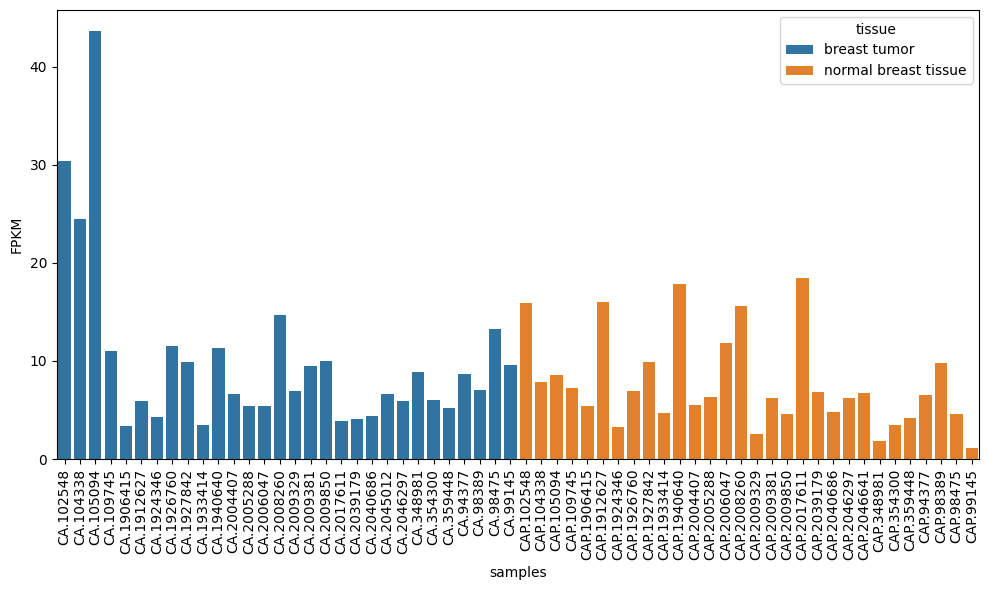

In [11]:
# Filter data
brca1_data = data_long[data_long['gene'] == 'BRCA1']

plt.figure(figsize=(10, 6))
# hue handles the 'fill' aesthetic; x and y specify axes
sns.barplot(data=brca1_data, x='samples', y='FPKM', hue='tissue', estimator=sum, ci=None)
plt.xticks(rotation=90) # Rotate sample names so they don't overlap

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "breast_cancer_barplot.png"))
plt.show()

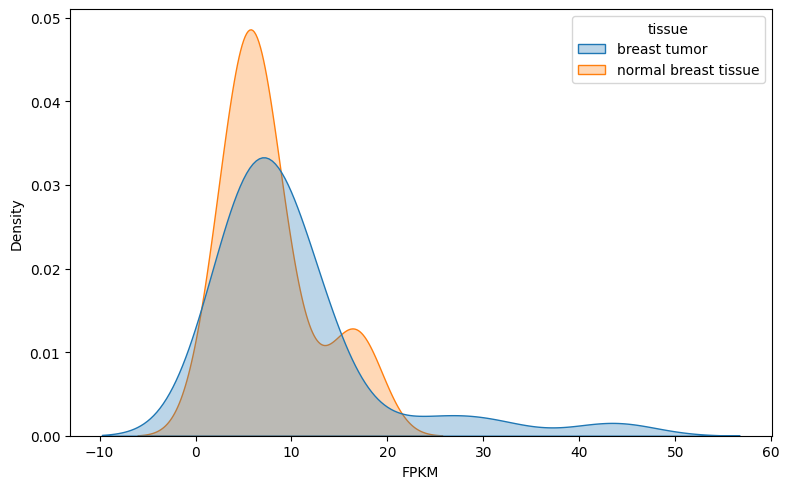

In [12]:
plt.figure(figsize=(8, 5))
# alpha sets transparency; common fill is handled by hue
sns.kdeplot(data=brca1_data, x='FPKM', hue='tissue', fill=True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "breast_cancer_density_plot.png"))
plt.show()

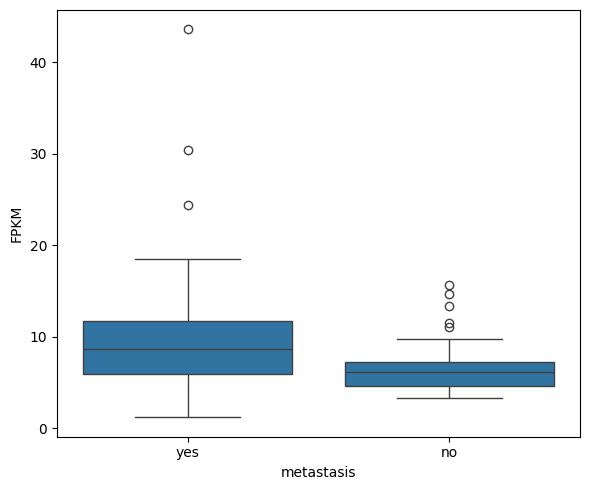

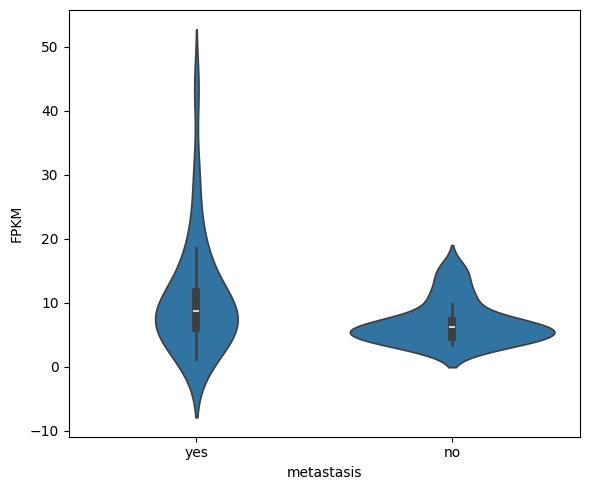

In [13]:
# Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=brca1_data, x='metastasis', y='FPKM')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "breast_cancer_boxplots.png"))
plt.show()

# Violin Plot
plt.figure(figsize=(6, 5))
sns.violinplot(data=brca1_data, x='metastasis', y='FPKM')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "breast_cancer_violin_plot.png"))
plt.show()

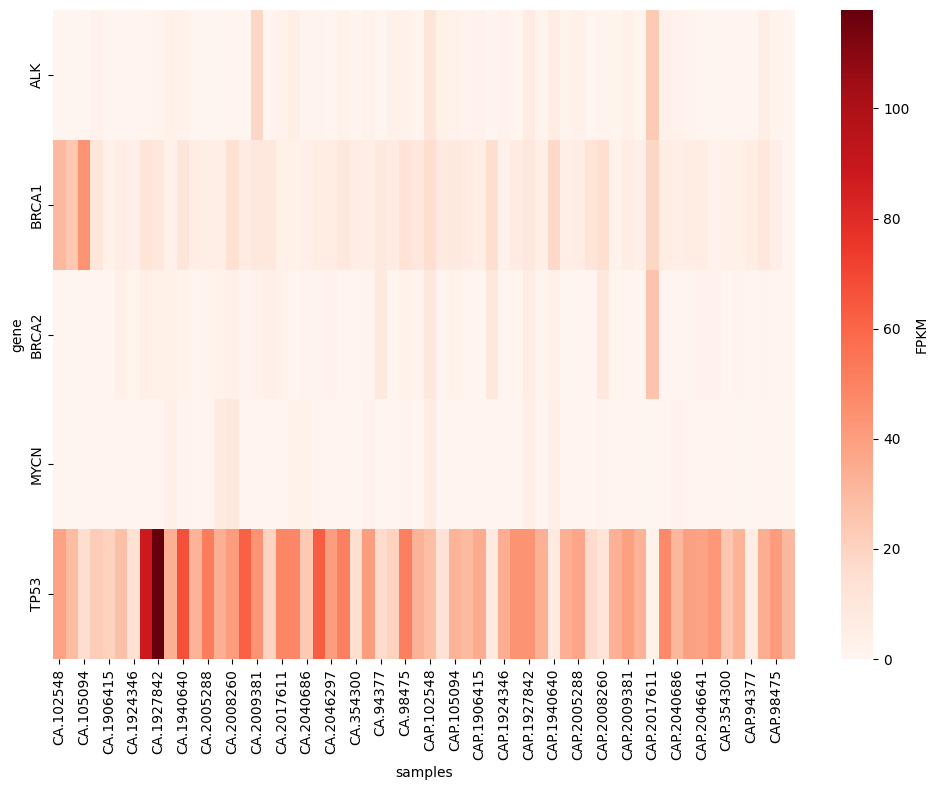

In [14]:
genes_of_interest = ['BRCA1', 'BRCA2', 'TP53', 'ALK', 'MYCN']
heatmap_df = data_long[data_long['gene'].isin(genes_of_interest)]

# Pivot to 2D matrix shape: Genes on rows, Samples on columns
heatmap_matrix = heatmap_df.pivot(index='gene', columns='samples', values='FPKM')

plt.figure(figsize=(10, 8))
# cmap sets the gradient profile (equivalent to scale_fill_gradient)
sns.heatmap(heatmap_matrix, cmap='Reds', cbar_kws={'label': 'FPKM'})

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "heatmap_save2.pdf"), format='pdf')
plt.show()